In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pympler import asizeof
from collections import defaultdict

In [10]:
bat_df = pd.read_pickle("../data/bat_df.pkl")

In [11]:
top_level_sizes = []

for col in bat_df.columns:
    total_size = 0
    non_null_count = 0

    for item in bat_df[col]:
        if item is not None:
            non_null_count += 1
            total_size += asizeof.asizeof(item)

    top_level_sizes.append({
        "column": col,
        "dtype": str(bat_df[col].dtype),
        "non_null_count": non_null_count,
        "estimated_size_MB": total_size / 1024**2
    })

top_level_size_df = pd.DataFrame(top_level_sizes)
top_level_size_df = top_level_size_df.sort_values("estimated_size_MB", ascending=False)

top_level_size_df

,column,dtype,non_null_count,estimated_size_MB
3,cycles,object,124,14031.033333
4,IR,object,124,1.577988
5,QC,object,124,1.577988
6,QD,object,124,1.577988
7,Tavg,object,124,1.577988
8,Tmin,object,124,1.577988
9,Tmax,object,124,1.577988
10,chargetime,object,124,1.577988
11,cycle,object,124,1.577988
2,charge_policy,object,124,0.008141


In [12]:
cycle_field_sizes = defaultdict(lambda: {
    "count": 0,
    "estimated_size_bytes": 0,
    "raw_array_nbytes": 0,
    "dtypes": defaultdict(int),
    "shapes": defaultdict(int),
    "example_type": None
})

for battery_idx, cycles in enumerate(bat_df["cycles"]):

    for cycle_num, cycle_data in cycles.items():
        for field, value in cycle_data.items():
            cycle_field_sizes[field]["count"] += 1
            cycle_field_sizes[field]["estimated_size_bytes"] += asizeof.asizeof(value)
            cycle_field_sizes[field]["example_type"] = type(value).__name__

            if isinstance(value, np.ndarray):
                cycle_field_sizes[field]["raw_array_nbytes"] += value.nbytes
                cycle_field_sizes[field]["dtypes"][str(value.dtype)] += 1
                cycle_field_sizes[field]["shapes"][value.shape] += 1
            else:
                cycle_field_sizes[field]["dtypes"][type(value).__name__] += 1

cycle_rows = []

for field, info in cycle_field_sizes.items():
    most_common_shapes = sorted(
        info["shapes"].items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    cycle_rows.append({
        "cycle_field": field,
        "count": info["count"],
        "example_type": info["example_type"],
        "estimated_size_MB": info["estimated_size_bytes"] / 1024**2,
        "raw_array_nbytes_MB": info["raw_array_nbytes"] / 1024**2,
        "dtypes": dict(info["dtypes"]),
        "most_common_shapes": most_common_shapes
    })

cycle_field_size_df = pd.DataFrame(cycle_rows)
cycle_field_size_df = cycle_field_size_df.sort_values(
    "estimated_size_MB",
    ascending=False
)

cycle_field_size_df

,cycle_field,count,example_type,estimated_size_MB,raw_array_nbytes_MB,dtypes,most_common_shapes
3,Qdlin,100501,ndarray,1568.937004,766.449600,"{'uint64': 41, 'float64': 100460}","[((1000,), 100460), ((2,), 41)]"
5,Tdlin,100501,ndarray,1568.937004,766.449600,"{'uint64': 41, 'float64': 100460}","[((1000,), 100460), ((2,), 41)]"
7,dQdV,100501,ndarray,1568.937004,766.449600,"{'uint64': 41, 'float64': 100460}","[((1000,), 100460), ((2,), 41)]"
0,I,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
1,Qc,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
2,Qd,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
4,T,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
6,V,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."
8,t,100501,ndarray,1546.759453,755.360825,"{'uint64': 41, 'float64': 100460}","[((742,), 522), ((749,), 500), ((746,), 493), ..."


| Column | Meaning | Description |
|---|---|---|
| `I` | Current | The current measured during the cycle. This shows how much electrical current is flowing during charge and discharge. |
| `Qc` | Charge capacity | The amount of capacity added to the battery during the charging portion of the cycle. |
| `Qd` | Discharge capacity | The amount of capacity delivered by the battery during the discharge portion of the cycle. This is useful for tracking battery degradation over time. |
| `T` | Temperature | The battery temperature measured throughout the cycle. |
| `V` | Voltage | The battery voltage measured throughout the cycle. This is useful for plotting voltage behavior over time or discharge capacity. |
| `t` | Time | The time values for the cycle. This is usually used as the x-axis when plotting voltage, current, or temperature. |
| `Qdlin` | Interpolated discharge capacity | The discharge capacity resampled to a fixed length of 1000 points. This makes it easier to compare cycles because every cycle has the same number of points. |
| `Tdlin` | Interpolated temperature | The temperature resampled to a fixed length of 1000 points, usually during discharge. |
| `dQdV` | Differential capacity | The derivative-like relationship between discharge capacity and voltage. It shows how discharge capacity changes with voltage and is often useful for battery health analysis. |

## Raw vs Interpolated Columns

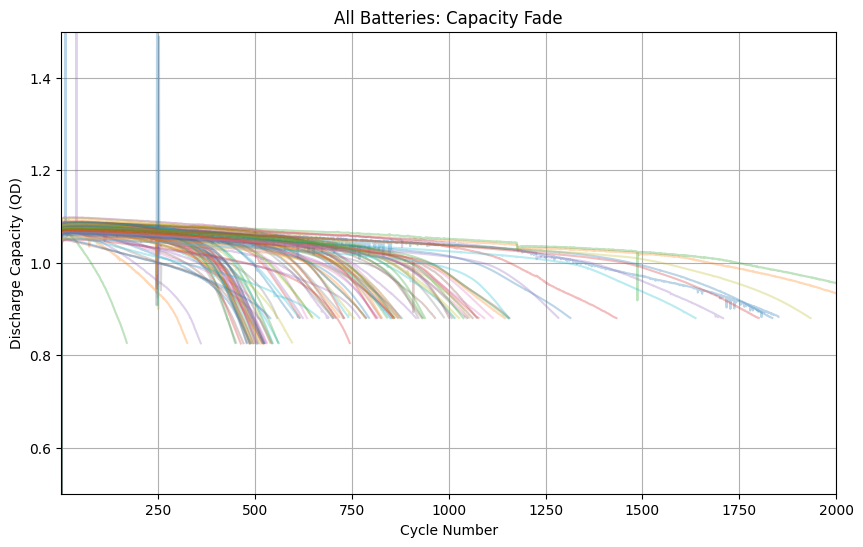

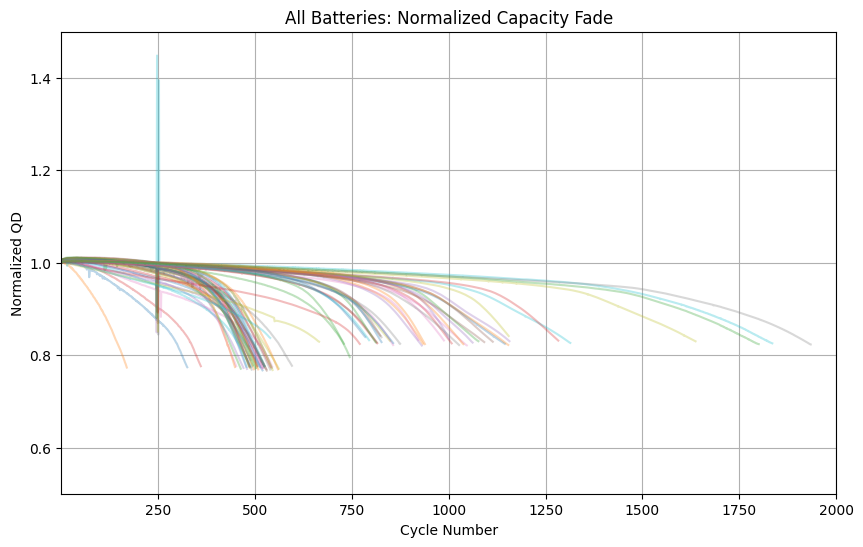

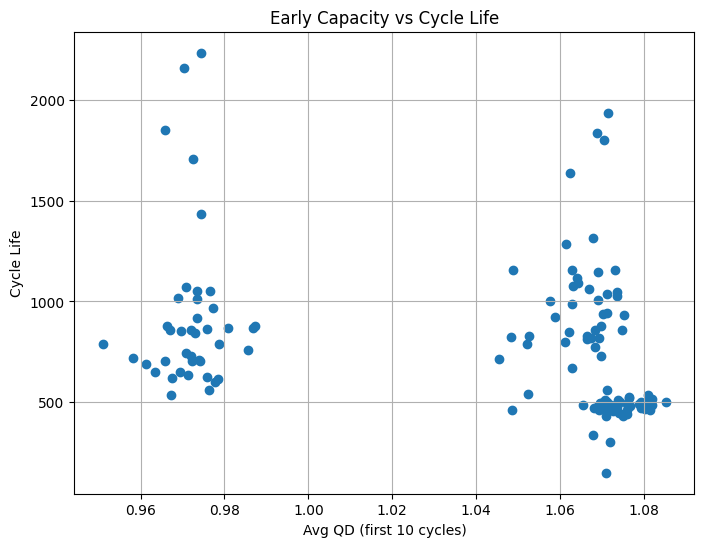

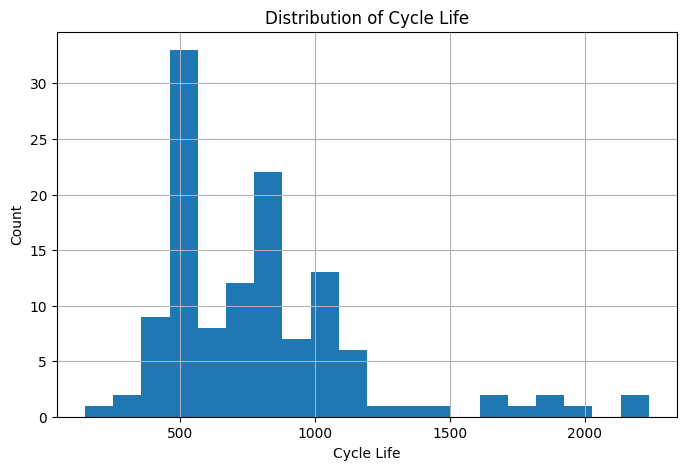

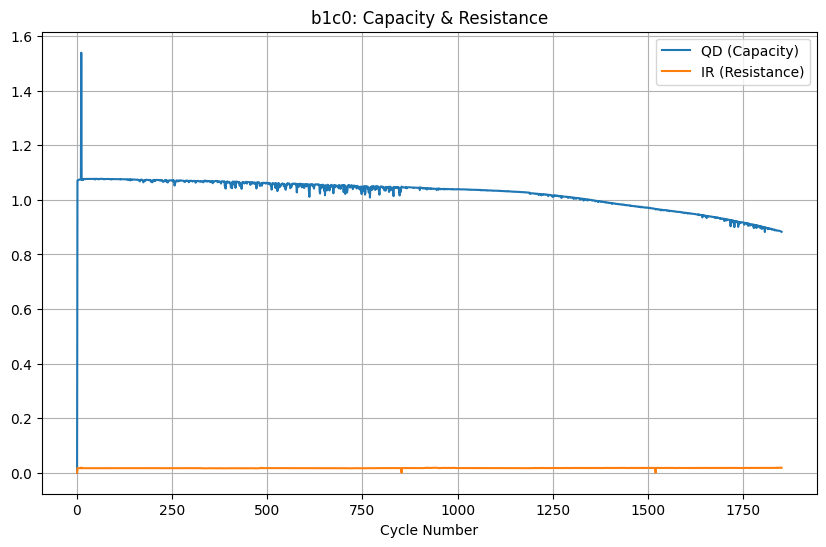

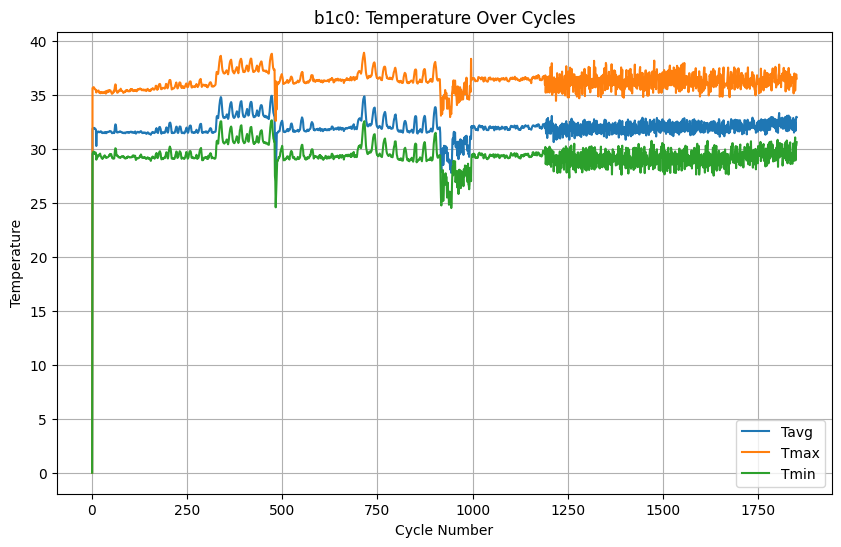

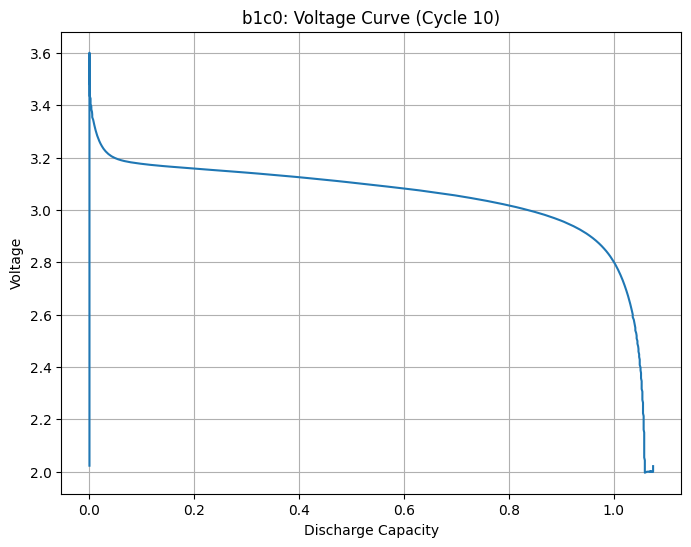

In [36]:
# ---------- Helper ----------
def arr(x):
    return np.asarray(x).squeeze()

# Pick one battery for detailed plots
battery = bat_df.iloc[0]
battery_id = battery["battery_id"]

# ---------- 1. ALL BATTERIES: Capacity fade ----------
plt.figure(figsize=(10, 6))
for _, row in bat_df.iterrows():
    plt.plot(arr(row["cycle"]), arr(row["QD"]), alpha=0.3)
plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (QD)")
plt.title("All Batteries: Capacity Fade")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5,1.5)
plt.show()


# ---------- 2. ALL BATTERIES: Normalized capacity ----------
plt.figure(figsize=(10, 6))
for _, row in bat_df.iterrows():
    qd = arr(row["QD"])
    if len(qd) > 0 and qd[0] != 0:
        plt.plot(arr(row["cycle"]), qd / qd[0], alpha=0.3)
plt.xlabel("Cycle Number")
plt.ylabel("Normalized QD")
plt.title("All Batteries: Normalized Capacity Fade")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5,1.5)
plt.show()


# ---------- 3. SCATTER: Early capacity vs cycle life ----------
early_qd = []
life = []

for _, row in bat_df.iterrows():
    qd = arr(row["QD"])
    if len(qd) >= 10:
        early_qd.append(np.mean(qd[:10]))
        life.append(row["cycle_life"])

plt.figure(figsize=(8, 6))
plt.scatter(early_qd, life)
plt.xlabel("Avg QD (first 10 cycles)")
plt.ylabel("Cycle Life")
plt.title("Early Capacity vs Cycle Life")
plt.grid(True)
plt.show()


# ---------- 4. HISTOGRAM: Cycle life ----------
plt.figure(figsize=(8, 5))
plt.hist(bat_df["cycle_life"], bins=20)
plt.xlabel("Cycle Life")
plt.ylabel("Count")
plt.title("Distribution of Cycle Life")
plt.grid(True)
plt.show()


# ---------- 5. SINGLE BATTERY: Capacity + IR ----------
plt.figure(figsize=(10, 6))
plt.plot(arr(battery["cycle"]), arr(battery["QD"]), label="QD (Capacity)")
plt.plot(arr(battery["cycle"]), arr(battery["IR"]), label="IR (Resistance)")
plt.xlabel("Cycle Number")
plt.title(f"{battery_id}: Capacity & Resistance")
plt.legend()
plt.grid(True)
plt.show()


# ---------- 6. SINGLE BATTERY: Temperature ----------
plt.figure(figsize=(10, 6))
plt.plot(arr(battery["cycle"]), arr(battery["Tavg"]), label="Tavg")
plt.plot(arr(battery["cycle"]), arr(battery["Tmax"]), label="Tmax")
plt.plot(arr(battery["cycle"]), arr(battery["Tmin"]), label="Tmin")
plt.xlabel("Cycle Number")
plt.ylabel("Temperature")
plt.title(f"{battery_id}: Temperature Over Cycles")
plt.legend()
plt.grid(True)
plt.show()


# ---------- 7. SINGLE CYCLE: Voltage curve ----------
cycle_key = list(battery["cycles"].keys())[10]  # pick ~cycle 10
cycle_data = battery["cycles"][cycle_key]

plt.figure(figsize=(8, 6))
plt.plot(arr(cycle_data["Qd"]), arr(cycle_data["V"]))
plt.xlabel("Discharge Capacity")
plt.ylabel("Voltage")
plt.title(f"{battery_id}: Voltage Curve (Cycle {cycle_key})")
plt.grid(True)
plt.show()

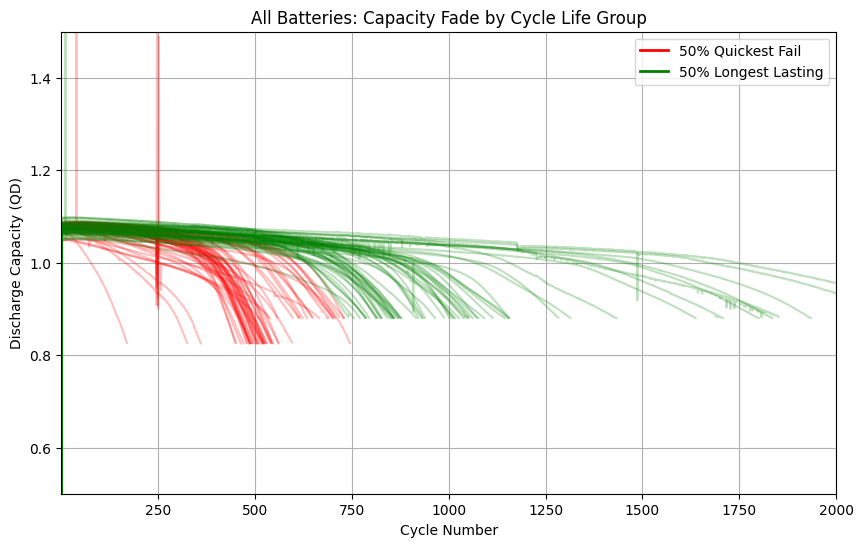

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ---------- Split batteries by cycle life ----------
cycle_life_median = bat_df["cycle_life"].median()

quick_fail_df = bat_df[bat_df["cycle_life"] <= cycle_life_median]
long_life_df = bat_df[bat_df["cycle_life"] > cycle_life_median]

# ---------- Plot ----------
plt.figure(figsize=(10, 6))

# 50% quickest fail batteries = red
for _, row in quick_fail_df.iterrows():
    plt.plot(
        arr(row["cycle"]),
        arr(row["QD"]),
        color="red",
        alpha=0.25
    )

# 50% longest lasting batteries = green
for _, row in long_life_df.iterrows():
    plt.plot(
        arr(row["cycle"]),
        arr(row["QD"]),
        color="green",
        alpha=0.25
    )

plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (QD)")
plt.title("All Batteries: Capacity Fade by Cycle Life Group")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5, 1.5)

legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="50% Quickest Fail"),
    Line2D([0], [0], color="green", lw=2, label="50% Longest Lasting")
]

plt.legend(handles=legend_elements)
plt.show()

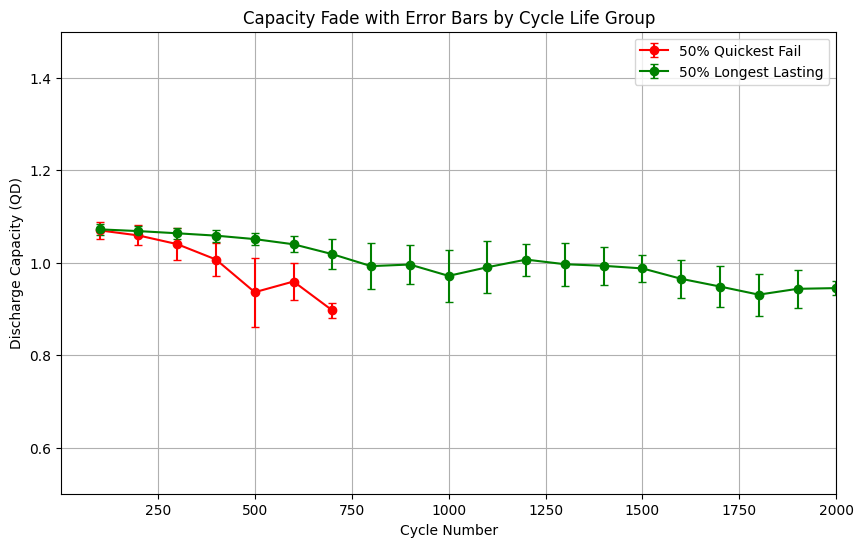

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------- Split batteries by cycle life ----------
cycle_life_median = bat_df["cycle_life"].median()

quick_fail_df = bat_df[bat_df["cycle_life"] <= cycle_life_median]
long_life_df = bat_df[bat_df["cycle_life"] > cycle_life_median]

# ---------- Helper: collect QD values at shared cycle numbers ----------
def get_group_stats(df, cycle_step=100):
    rows = []

    for _, row in df.iterrows():
        cycles = arr(row["cycle"]).astype(float)
        qd = arr(row["QD"]).astype(float)

        for c in range(0, int(np.nanmax(cycles)) + 1, cycle_step):
            idx = np.where(cycles == c)[0]

            if len(idx) > 0:
                rows.append({
                    "cycle": c,
                    "QD": qd[idx[0]]
                })

    stats_df = pd.DataFrame(rows)

    group_stats = stats_df.groupby("cycle")["QD"].agg(
        mean="mean",
        std="std",
        count="count"
    ).reset_index()

    group_stats["sem"] = group_stats["std"] / np.sqrt(group_stats["count"])

    return group_stats

quick_stats = get_group_stats(quick_fail_df, cycle_step=100)
long_stats = get_group_stats(long_life_df, cycle_step=100)

# ---------- Plot mean with error bars ----------
plt.figure(figsize=(10, 6))

plt.errorbar(
    quick_stats["cycle"],
    quick_stats["mean"],
    yerr=quick_stats["std"],   # use std for spread
    color="red",
    marker="o",
    capsize=3,
    label="50% Quickest Fail"
)

plt.errorbar(
    long_stats["cycle"],
    long_stats["mean"],
    yerr=long_stats["std"],    # use std for spread
    color="green",
    marker="o",
    capsize=3,
    label="50% Longest Lasting"
)

plt.xlabel("Cycle Number")
plt.ylabel("Discharge Capacity (QD)")
plt.title("Capacity Fade with Error Bars by Cycle Life Group")
plt.grid(True)
plt.xlim(1, 2000)
plt.ylim(0.5, 1.5)
plt.legend()
plt.show()

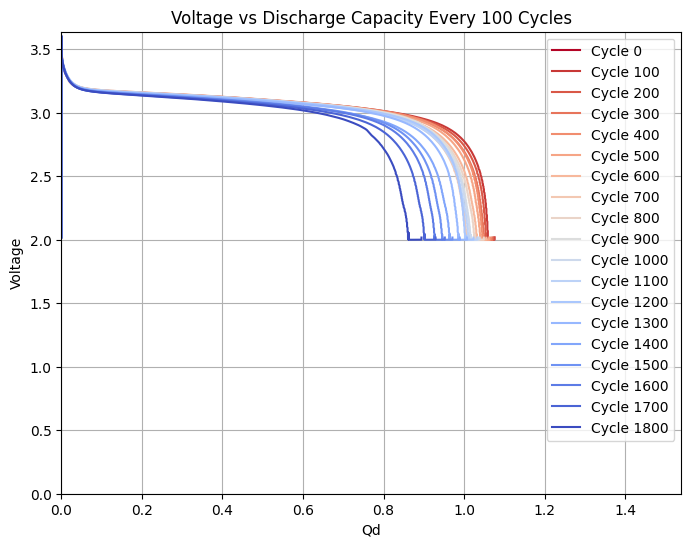

In [17]:
battery = bat_df.iloc[0]

# ---------- Compute global limits ----------
all_Qd = []
all_V = []

for k in battery["cycles"]:
    cd = battery["cycles"][k]
    all_Qd.append(arr(cd["Qd"]))
    all_V.append(arr(cd["V"]))

all_Qd = np.concatenate(all_Qd)
all_V = np.concatenate(all_V)

x_min, x_max = all_Qd.min(), all_Qd.max()
y_min, y_max = all_V.min(), all_V.max()

# ---------- Plot every 100 cycles on same graph ----------
plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    plt.plot(
        arr(cd["Qd"]),
        arr(cd["V"]),
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Qd")
plt.ylabel("Voltage")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Voltage vs Discharge Capacity Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

Skipping cycle 0: invalid Qd_max = 0.0


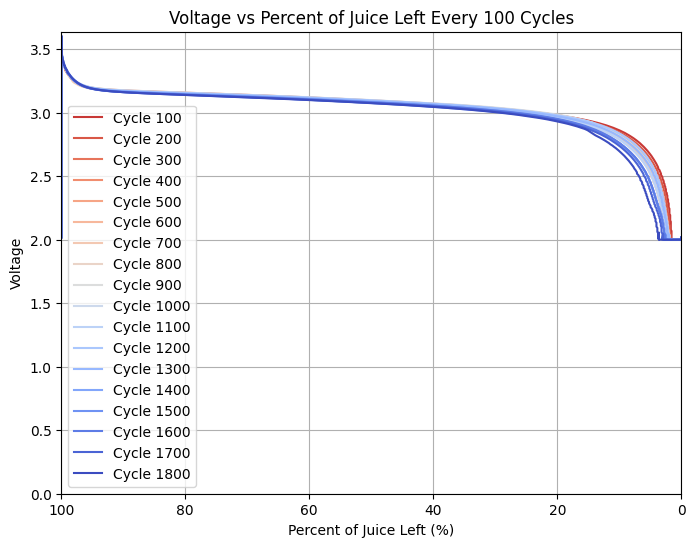

In [21]:
battery = bat_df.iloc[0]

# ---------- Compute global voltage limits ----------
all_V = []

for k in battery["cycles"]:
    cd = battery["cycles"][k]
    V = arr(cd["V"])

    if len(V) > 0:
        all_V.append(V)

all_V = np.concatenate(all_V)
y_min, y_max = np.nanmin(all_V), np.nanmax(all_V)

# ---------- Plot every 100 cycles on same graph ----------
plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    Qd = arr(cd["Qd"]).astype(float)
    V = arr(cd["V"]).astype(float)

    # Skip empty or invalid cycles
    if len(Qd) == 0 or len(V) == 0:
        print(f"Skipping cycle {k}: empty Qd or V")
        continue

    Qd_max = np.nanmax(Qd)

    # Skip cycles where Qd does not increase
    if Qd_max == 0 or np.isnan(Qd_max):
        print(f"Skipping cycle {k}: invalid Qd_max = {Qd_max}")
        continue

    # Percent juice left during discharge
    percent_left = 100 * (1 - Qd / Qd_max)

    plt.plot(
        percent_left,
        V,
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Percent of Juice Left (%)")
plt.ylabel("Voltage")
plt.xlim(100, 0)  # full on left, empty on right
plt.ylim(y_min, y_max)
plt.title("Voltage vs Percent of Juice Left Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

Skipping cycle 0: invalid Qd_max = 0.0


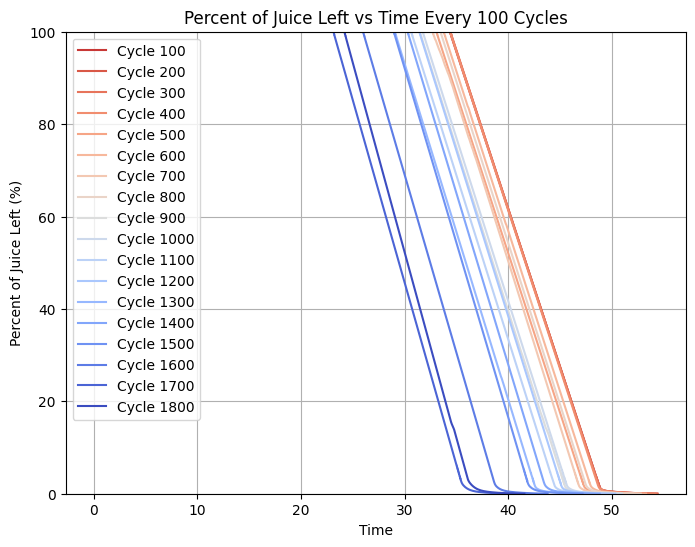

In [23]:
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    Qd = arr(cd["Qd"]).astype(float)
    t = arr(cd["t"]).astype(float)

    # Skip empty or invalid cycles
    if len(Qd) == 0 or len(t) == 0:
        print(f"Skipping cycle {k}: empty Qd or t")
        continue

    Qd_max = np.nanmax(Qd)

    if Qd_max == 0 or np.isnan(Qd_max):
        print(f"Skipping cycle {k}: invalid Qd_max = {Qd_max}")
        continue

    # Percent juice left during discharge
    percent_left = 100 * (1 - Qd / Qd_max)

    plt.plot(
        t,
        percent_left,
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Time")
plt.ylabel("Percent of Juice Left (%)")
plt.ylim(0, 100)
plt.title("Percent of Juice Left vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

Skipping cycle 0: no discharge region found


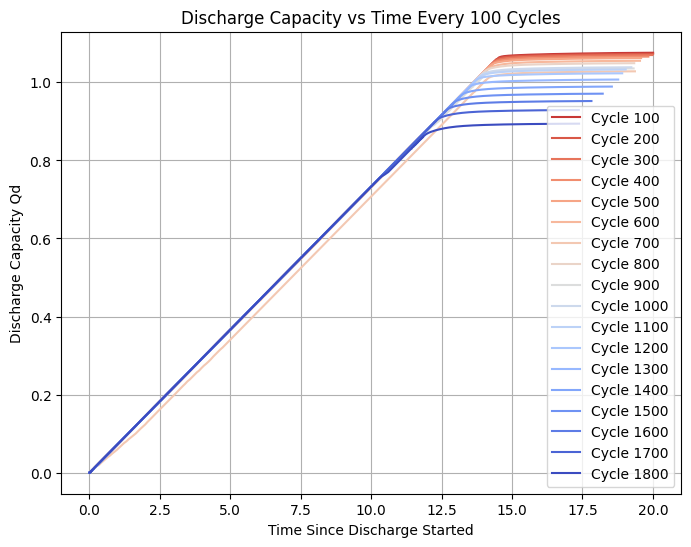

In [34]:
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    Qd = arr(cd["Qd"]).astype(float)
    t = arr(cd["t"]).astype(float)
    I = arr(cd["I"]).astype(float)

    # Skip empty or invalid cycles
    if len(Qd) == 0 or len(t) == 0 or len(I) == 0:
        print(f"Skipping cycle {k}: empty Qd, t, or I")
        continue

    # Use current to identify real discharge portion
    # Negative current means discharging
    discharge_mask = I < -1e-3  # small threshold to avoid noise

    if not np.any(discharge_mask):
        print(f"Skipping cycle {k}: no discharge region found")
        continue

    Qd_discharge = Qd[discharge_mask]
    t_discharge = t[discharge_mask]

    # Reset time so discharge starts at t = 0
    t_discharge = t_discharge - t_discharge[0]

    # Reset Qd so discharge starts at Qd = 0
    Qd_discharge = Qd_discharge - Qd_discharge[0]

    plt.plot(
        t_discharge,
        Qd_discharge,
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Time Since Discharge Started")
plt.ylabel("Discharge Capacity Qd")
plt.title("Discharge Capacity vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

Skipping cycle 0: invalid Qc_max = 0.0


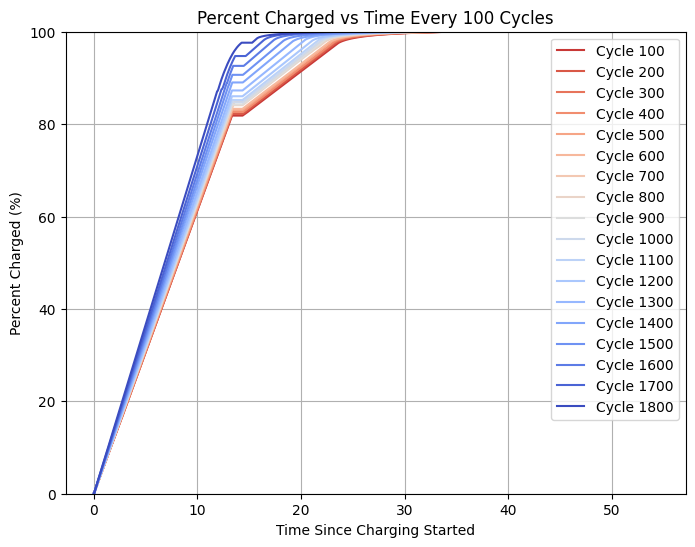

In [27]:
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    Qc = arr(cd["Qc"]).astype(float)
    t = arr(cd["t"]).astype(float)

    # Skip empty or invalid cycles
    if len(Qc) == 0 or len(t) == 0:
        print(f"Skipping cycle {k}: empty Qc or t")
        continue

    Qc_max = np.nanmax(Qc)

    if Qc_max == 0 or np.isnan(Qc_max):
        print(f"Skipping cycle {k}: invalid Qc_max = {Qc_max}")
        continue

    # Keep only the charging portion
    charging_mask = Qc > 0
    Qc_charge = Qc[charging_mask]
    t_charge = t[charging_mask]

    if len(Qc_charge) == 0 or len(t_charge) == 0:
        print(f"Skipping cycle {k}: no charging region found")
        continue

    # Reset time so charging starts at t = 0
    t_charge = t_charge - t_charge[0]

    # Percent charged
    percent_charged = 100 * (Qc_charge / Qc_max)

    plt.plot(
        t_charge,
        percent_charged,
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Time Since Charging Started")
plt.ylabel("Percent Charged (%)")
plt.ylim(0, 100)
plt.title("Percent Charged vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

Skipping cycle 0: invalid Qc_max = 0.0


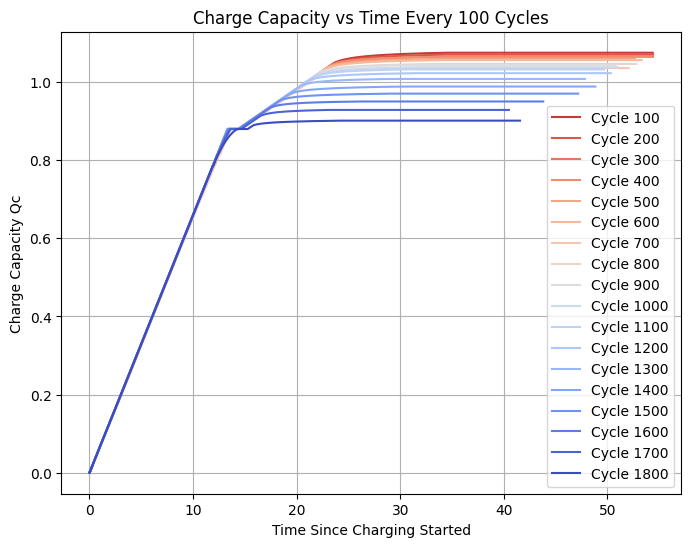

In [28]:
battery = bat_df.iloc[0]

plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    Qc = arr(cd["Qc"]).astype(float)
    t = arr(cd["t"]).astype(float)

    # Skip empty or invalid cycles
    if len(Qc) == 0 or len(t) == 0:
        print(f"Skipping cycle {k}: empty Qc or t")
        continue

    Qc_max = np.nanmax(Qc)

    if Qc_max == 0 or np.isnan(Qc_max):
        print(f"Skipping cycle {k}: invalid Qc_max = {Qc_max}")
        continue

    # Keep only the charging portion
    charging_mask = Qc > 0
    Qc_charge = Qc[charging_mask]
    t_charge = t[charging_mask]

    if len(Qc_charge) == 0 or len(t_charge) == 0:
        print(f"Skipping cycle {k}: no charging region found")
        continue

    # Reset time so charging starts at t = 0
    t_charge = t_charge - t_charge[0]

    plt.plot(
        t_charge,
        Qc_charge,
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Time Since Charging Started")
plt.ylabel("Charge Capacity Qc")
plt.title("Charge Capacity vs Time Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

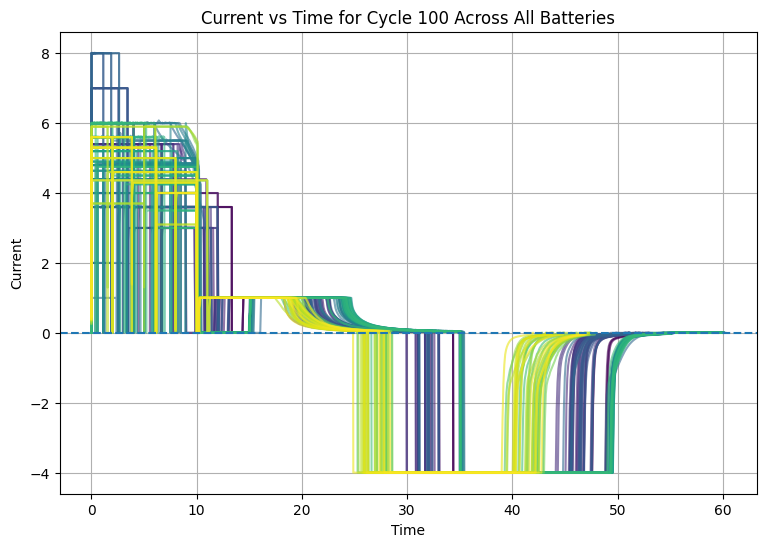

In [26]:
import numpy as np
import matplotlib.pyplot as plt

cycle_to_plot = "100"

plt.figure(figsize=(9, 6))

num_batteries = len(bat_df)
colors = plt.cm.viridis(np.linspace(0, 1, num_batteries))

for i, (_, battery) in enumerate(bat_df.iterrows()):
    cycles = battery["cycles"]

    # Skip batteries that do not have cycle 100
    if cycle_to_plot not in cycles:
        print(f"Skipping battery {i}: no cycle {cycle_to_plot}")
        continue

    cd = cycles[cycle_to_plot]

    t = arr(cd["t"]).astype(float)
    I = arr(cd["I"]).astype(float)

    if len(t) == 0 or len(I) == 0:
        print(f"Skipping battery {i}: empty t or I")
        continue

    plt.plot(
        t,
        I,
        color=colors[i],
        alpha=0.6,
        label=f"Battery {i}"
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Current")
plt.title(f"Current vs Time for Cycle {cycle_to_plot} Across All Batteries")
plt.grid(True)

# Legend can get huge with 124 batteries, so put it outside or remove it
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)

plt.show()

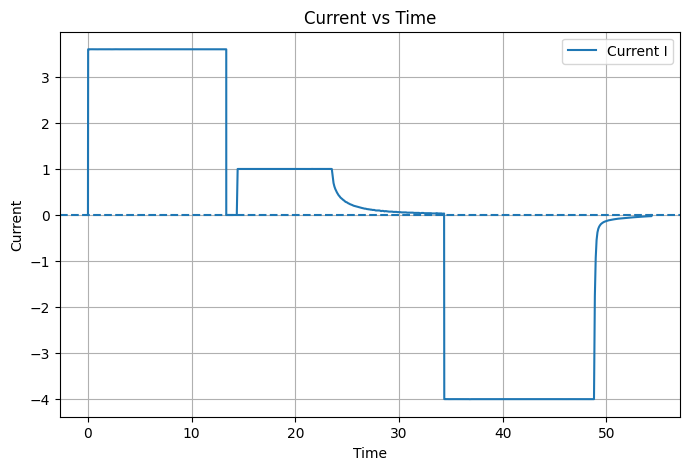

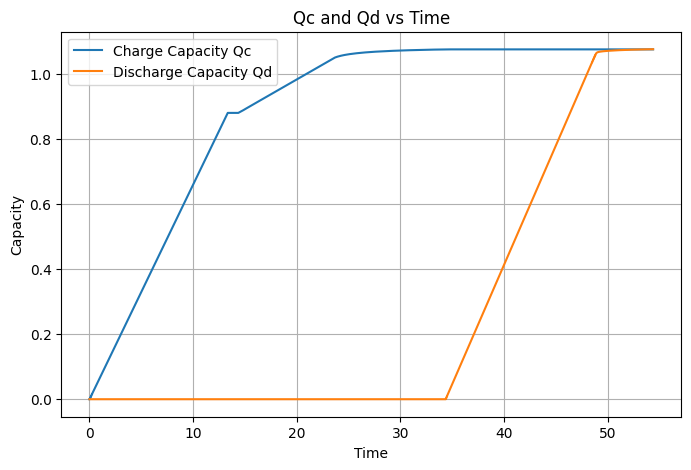

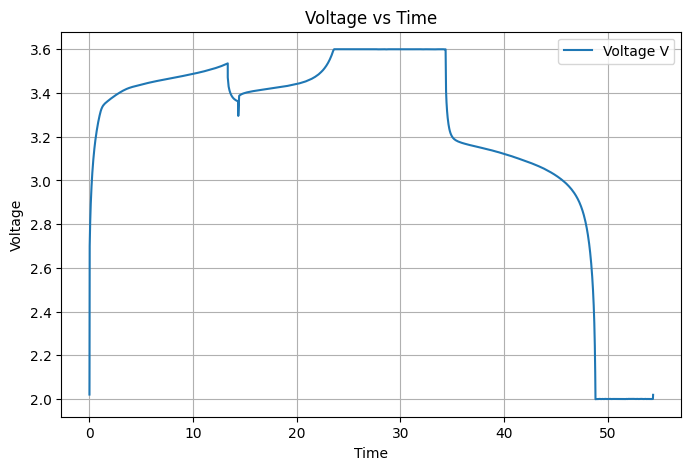

In [24]:
battery = bat_df.iloc[0]
cd = battery["cycles"]["100"]

t = arr(cd["t"]).astype(float)
I = arr(cd["I"]).astype(float)
Qc = arr(cd["Qc"]).astype(float)
Qd = arr(cd["Qd"]).astype(float)
V = arr(cd["V"]).astype(float)

plt.figure(figsize=(8, 5))
plt.plot(t, I, label="Current I")
plt.axhline(0, linestyle="--")
plt.xlabel("Time")
plt.ylabel("Current")
plt.title("Current vs Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t, Qc, label="Charge Capacity Qc")
plt.plot(t, Qd, label="Discharge Capacity Qd")
plt.xlabel("Time")
plt.ylabel("Capacity")
plt.title("Qc and Qd vs Time")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(t, V, label="Voltage V")
plt.xlabel("Time")
plt.ylabel("Voltage")
plt.title("Voltage vs Time")
plt.grid(True)
plt.legend()
plt.show()

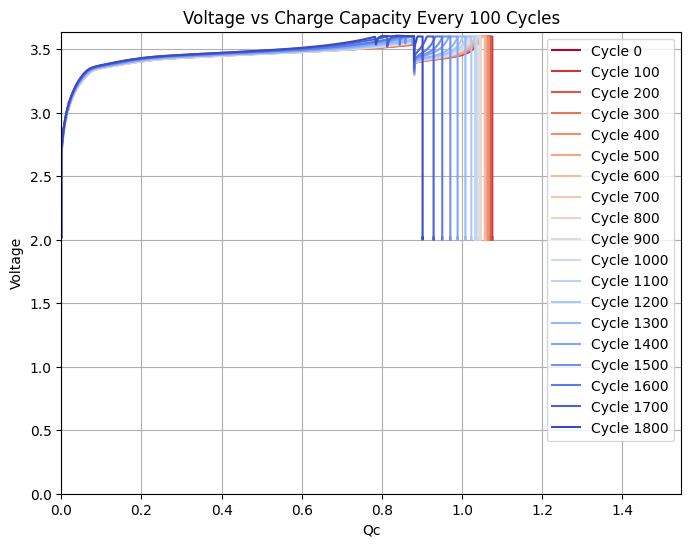

In [19]:
battery = bat_df.iloc[0]

# ---------- Compute global limits ----------
all_Qd = []
all_V = []

for k in battery["cycles"]:
    cd = battery["cycles"][k]
    all_Qd.append(arr(cd["Qc"]))
    all_V.append(arr(cd["V"]))

all_Qd = np.concatenate(all_Qd)
all_V = np.concatenate(all_V)

x_min, x_max = all_Qd.min(), all_Qd.max()
y_min, y_max = all_V.min(), all_V.max()

# ---------- Plot every 100 cycles on same graph ----------
plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 100))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    plt.plot(
        arr(cd["Qc"]),
        arr(cd["V"]),
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Qc")
plt.ylabel("Voltage")
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.title("Voltage vs Charge Capacity Every 100 Cycles")
plt.grid(True)
plt.legend()
plt.show()

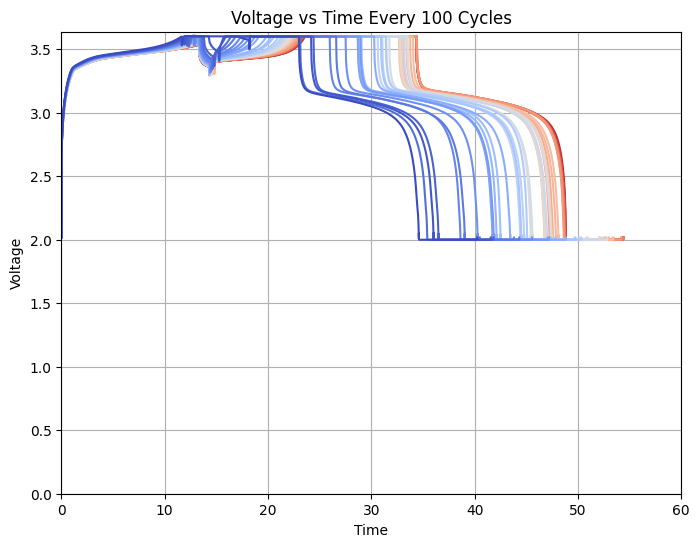

In [18]:
battery = bat_df.iloc[0]

# ---------- Compute global voltage limits ----------
all_V = []

for k in battery["cycles"]:
    cd = battery["cycles"][k]
    all_V.append(arr(cd["V"]))

all_V = np.concatenate(all_V)

y_min, y_max = all_V.min(), all_V.max()

# ---------- Plot Voltage vs Time every 100 cycles ----------
plt.figure(figsize=(8, 6))

num_cycles = len(battery["cycles"])
cycle_nums = list(range(0, num_cycles, 50))

# Red -> Blue gradient
colors = plt.cm.coolwarm_r(np.linspace(0, 1, len(cycle_nums)))

for i, k in enumerate(cycle_nums):
    cd = battery["cycles"][str(k)]

    plt.plot(
        arr(cd["t"]),
        arr(cd["V"]),
        color=colors[i],
        label=f"Cycle {k}"
    )

plt.xlabel("Time")
plt.ylabel("Voltage")
plt.xlim(0, 60)
plt.ylim(y_min, y_max)
plt.title("Voltage vs Time Every 100 Cycles")
plt.grid(True)
# plt.legend()
plt.show()